# T³ CAN: Activity Manifold Topology


Quick notebook for devlopment of the T^3 torus. Checking if the CAN produces the expected activity Manifold. Following the structure of the MADE tutorial:

https://github.com/FieteLab/MADE/blob/main/made/notebooks/2_visualize_activity_manifold.ipynb


In [ ]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from loguru import logger
from persim import plot_diagrams

sys.path.insert(0, os.path.abspath("../.."))

from model.network import torus3D_manifold, visualize3D, utils3D
from model.network.CAN3D import CAN3D, Kernel_BF, kernel_field_on_grid


# Setup parameters and build the CAN


In [ ]:
N_PER_AXIS = 15
N_SETTLE   = 400
N_RESETTLE = 50

SPACING       = 0.3
lambda_net    = 2.5
ratio         = 1.05
target_margin = 3.0
B             = 0.3

manifold = torus3D_manifold.TorusND(dim=3)
n = int(np.ceil(2 * np.pi / SPACING))                 # 21 per axis

kernel   = Kernel_BF(lambda_net=lambda_net, ratio=ratio, alpha=1.0)
vol = kernel_field_on_grid(kernel, manifold.metric, n)
Wk = np.fft.fftn(vol).real
dc = float(Wk.flat[0])
Wf = Wk.copy(); Wf.flat[0] = -np.inf
peak = float(Wf.max())
kernel.alpha = target_margin / peak                     # <-- target_margin now used

can = CAN3D(manifold, kernel=kernel, spacing=SPACING, alpha=3.0, sigma=3.0, b=B,
            build_connectivity=True, dt=0.1)  

print(can)


CAN3D(manifold=Torus3D(dim=3, parameter_space=ParameterSpace3D(ranges=[Range(start=0, end=6.283185307179586, periodic=True), Range(start=0, end=6.283185307179586, periodic=True), Range(start=0, end=6.283185307179586, periodic=True)]), metric=<made.metrics.PeriodicEuclidean object at 0x148a9bfd0>), spacing=0.3, alpha=3.0, sigma=3.0, tau=5, weights_offset=<function default_weights_offset at 0x146899800>, b=0.3, build_connectivity=True, kernel=Kernel_BF(lambda_net=2.5, ratio=1.05, a=1.0, gain=1.1814839285666605, sigma_i=1.0206207261596576, sigma_e=0.9960238411119947), dt=0.1)


Setlle reference lattice

std=0.0109, min=0.0001, max=0.0695


(<Figure size 1500x400 with 6 Axes>,
 array([<Axes: title={'center': 'State, fix θ₃=2.39'}, xlabel='theta_1', ylabel='theta_2'>,
        <Axes: title={'center': 'State, fix θ₁=1.20'}, xlabel='theta_2', ylabel='theta_3'>,
        <Axes: title={'center': 'State, fix θ₂=0.00'}, xlabel='theta_1', ylabel='theta_3'>],
       dtype=object))

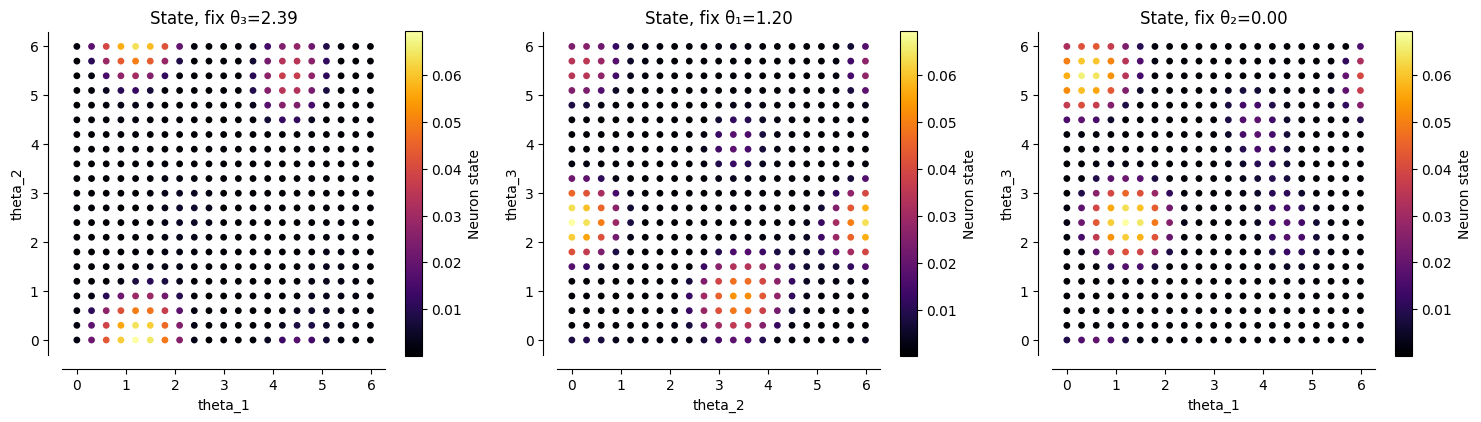

In [ ]:
can.reset(mode="random")
for _ in range(N_SETTLE):
    can()

assert can.S.std() > 0.01, f"Network settled to uniform state (std={can.S.std():.2e}) — lattice did not form"
print(f"std={can.S.std():.4f}, min={can.S.min():.4f}, max={can.S.max():.4f}")


n1, n2, n3 = can.nx(0), can.nx(1), can.nx(2)
ref3d = can.S.reshape(n1, n2, n3).copy()

visualize3D.visualize_can_state_3d(can)

In [ ]:
print(f'Can min {can.S.min()}'
      f'can max {can.S.max()}' 
      f' Can std {can.S.std()}')

Can min 5.8529684213682905e-05can max 0.06949679168608863 Can std 0.01093272790530449


Generate target phases

/Users/jacobhornsvennevik/Documents/GitHub/CAN_Path_Integration_3D_model/model/network/visualize3D.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/Users/jacobhornsvennevik/Documents/GitHub/CAN_Path_Integration_3D_model/model/network/visualize3D.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/Users/jacobhornsvennevik/Documents/GitHub/CAN_Path_Integration_3D_model/model/network/visualize3D.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'θ₁ vs θ₂'}, xlabel='θ₁', ylabel='θ₂'>,
        <Axes: title={'center': 'θ₂ vs θ₃'}, xlabel='θ₂', ylabel='θ₃'>,
        <Axes: title={'center': 'θ₁ vs θ₃'}, xlabel='θ₁', ylabel='θ₃'>],
       dtype=object))

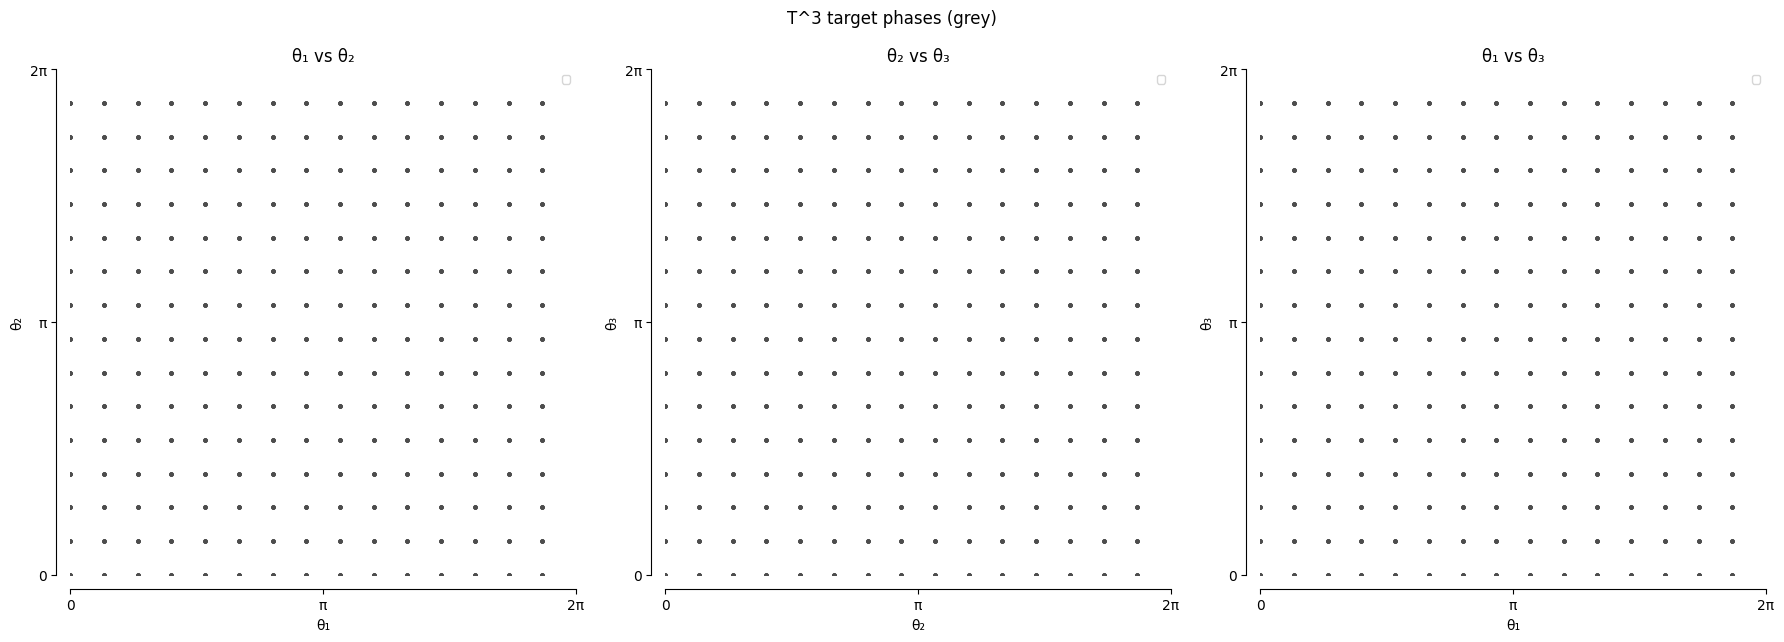

In [ ]:
gx, gy, gz = (np.linspace(0, n, N_PER_AXIS, endpoint=False) for n in (n1, n2, n3))
injected = np.array([(x, y, z) for x in gx for y in gy for z in gz])
injected_rad = injected / np.array([n1, n2, n3]) * 2*np.pi

visualize3D._plot_marginals(injected_rad, "T^3 target phases (grey)",
                            color=[0.3, 0.3, 0.3], alpha=0.3, s=5)

## Simulations



In [ ]:
final_states = utils3D.shift_and_settle(can, ref3d, injected, n_resettle=N_RESETTLE)
logger.info(f"Final states shape: {final_states.shape}")

Settling phases:   1%|▏         | 46/3375 [03:12<3:51:43,  4.18s/it]


KeyboardInterrupt: 

Visualise settled states 

In [ ]:
recovered = utils3D.recover_phases(final_states, ref3d)
recovered_rad = recovered / np.array([n1, n2, n3]) * 2*np.pi

visualize3D._plot_marginals(recovered_rad, "Recovered phases on T³",
                            color="red", alpha=0.3, s=12)

## 3. Visualize the activity manifold
Use PCA (dimensionality reduction) who takes each bump state witch is a point in 2197 dimensional space (n = 13) and reduces this down to 3 numbers (theta_1, theta_2 and theta_3). Since we want to vosualise the slice in 3D we also need curvature, so we use 50 components

Then takes this reduction and finds a 3D representasion based on how far each of these points are from eachother.

In [ ]:
visualize3D.plot_isomap_slices(
    final_states, injected_rad, can,
    n_slices=4, elev=15, azim=0,
)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

def plot_isomap_full(final_states, injected_rad, n_pca=50, n_neighbors=8, elev=15, azim=0):
    """
    Run Isomap on all states at once, colour by injected θ₃ phase.
    Simpler and more robust than slicing for small N_PER_AXIS.
    """
    states_pca = PCA(n_components=n_pca).fit_transform(final_states)
    embedding  = Isomap(n_components=3, n_neighbors=n_neighbors).fit_transform(states_pca)
    
    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection="3d")
    sc  = ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2],
                     c=injected_rad[:, 2], cmap="hsv", s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax, label="θ₃ (injected)")
    ax.set_title("Isomap of all settled states, coloured by θ₃")
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    return fig, ax

plot_isomap_full(
    final_states, injected_rad,
    elev=15, azim=0,
)
plt.show()

In [ ]:
from model.network.CAN3D import kernel_field_on_grid

row = np.asarray(can.connectivity_matrix)[0].reshape(n, n, n)   # weights from neuron 0
ref = kernel_field_on_grid(can.kernel, manifold.metric, n)      # kernel on the lattice
print("max |row - ref| =", np.abs(row - ref).max())             # want ~0

Wk = np.fft.fftn(row).real
Wf = Wk.copy(); Wf.flat[0] = -np.inf
print(f"actual peak = {Wf.max():.4f}  (want {target_margin})   actual dc = {Wk[0,0,0]:.2f}")


max |row - ref| = 2.636779683484747e-16
actual peak = 3.0000  (want 3.0)   actual dc = -50.86


In [ ]:
S = np.random.rand(*can.S.shape)
manual = S + (can.dt/can.tau)*(np.maximum(0., can.connectivity_matrix @ S + can.b) - S)
can.S = S.copy(); can()
print("step matches step_stateless:", np.allclose(manual, can.S))

step matches step_stateless: True
